# **Analítica Computacional para la toma de Decisiones Avanzada – Taller 6 202610**

## Clasificación con Redes Neuronales- Iris

Tome como base el modelo de redes neuronales presentado en el cuaderno de la clase
para predecir la especie de una planta con base en los datos Iris.

---

Daniel Benavides - 202220428 - <d.benavidess@uniandes.edu.co>

Juanita Cortés - 202222129 - <jv.cortesv1@uniandes.edu.co>

In [41]:
import tensorflow as tf
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [42]:
iris = load_iris()

print(iris.data[0:3,])
print(iris.target[0:3,])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
[0 0 0]


1. Seleccione una de las especies y cree una variable de respuesta binaria que sea 1 cuando la observación corresponda a la especie seleccionada y 0 de lo contrario. 

In [43]:

y = iris.target
X = iris.data
# crear variable binaria
y_binary = (y == 0).astype(int)

print("Número de observaciones:", len(y_binary))
print("Número de setosa:", sum(y_binary))
print("Número de no setosa:", len(y_binary) - sum(y_binary))

Número de observaciones: 150
Número de setosa: 50
Número de no setosa: 100


2. Crear un modelo usando Keras y TensorFlow para predecir si la planta pertenece a la especie seleccionada

In [44]:
#separemos las variables
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42
)

#escalar las variables 
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

2.1. Construir modelo base


In [45]:
model = tf.keras.Sequential([
    #primer capa y recibe 4 variables con base en Iris
    tf.keras.layers.Dense(8, activation='relu', input_shape=(4,)),
    #segunda capa
    tf.keras.layers.Dense(4, activation='relu'),
    #para que la salida sea binaria usamos una función sigmpode
    tf.keras.layers.Dense(1, activation='sigmoid')
])

c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2.2 Compilar el modelo

In [46]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

3. Entrene este nuevo modelo, grafique el historial de p´erdida de entrenamiento y
validaci´on, calcule todas las m´etricas vistas en clase para evaluar modelos de
clasificaci´on (accuracy, precision, recall, etc) y comente sus resultados en su reporte.

In [47]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 339ms/step - accuracy: 0.5078 - loss: 0.7119 - val_accuracy: 0.7500 - val_loss: 0.6781
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5039 - loss: 0.7052 - val_accuracy: 0.7917 - val_loss: 0.6751
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5807 - loss: 0.7010 - val_accuracy: 0.7917 - val_loss: 0.6719
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6562 - loss: 0.6956 - val_accuracy: 0.8750 - val_loss: 0.6680
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6784 - loss: 0.6904 - val_accuracy: 0.9167 - val_loss: 0.6636
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7396 - loss: 0.6911 - val_accuracy: 0.9167 - val_loss: 0.6595
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7344 - loss: 0.6900 - val_accuracy: 0.9583 - val_loss: 0.6555
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7474 - loss: 0.6846 - val_accuracy: 0.9583 - val_loss: 0.651

3.1. Graficar historial de pérdida

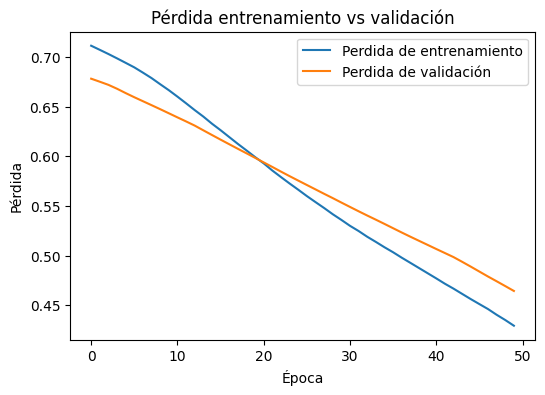

In [48]:

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Perdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Perdida de validación')

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Pérdida entrenamiento vs validación")
plt.legend()

plt.show()

3.2. Calcular métricas de clasificación

In [49]:
y_prob = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


In [50]:
y_pred = (y_prob > 0.5).astype(int)

In [51]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import numpy as np

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

specificity = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

auc = roc_auc_score(y_test, y_prob)

print("Matriz de confusión:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1:", f1)
print("ROC-AUC:", auc)


Matriz de confusión:
 [[20  0]
 [ 0 10]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Specificity: 1.0
FPR: 0.0
FNR: 0.0
F1: 1.0
ROC-AUC: 1.0


4. Modifique el n´umero de neuronas y capas (3 casos diferentes al modelo base), entrene
los modelos resultantes y compare las m´etricas obtenidas. Use siempre los mismos
datos de entrenamiento y prueba. Comente sus resultados en su reporte

In [52]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

def evaluar_modelo(model, X_train, y_train, X_test, y_test):

    history = model.fit(
        X_train, y_train,
        epochs=50,
        validation_split=0.2,
        verbose=0
    )

    y_prob = model.predict(X_test, verbose=0)
    y_pred = (y_prob > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    resultados = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "specificity": tn / (tn + fp),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob)
    }

    return resultados

In [53]:
#Modelo de red pequeña
#una sola capa oculta con 4 neuronas ( salida, sigmoide)
model_A = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

res_A = evaluar_modelo(model_A, X_train, y_train, X_test, y_test)

c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
#Modelo de red más profunda

model_B = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_B.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

res_B = evaluar_modelo(model_B, X_train, y_train, X_test, y_test)

c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
#Modelo de red más grande
model_C = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_C.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

res_C = evaluar_modelo(model_C, X_train, y_train, X_test, y_test)

c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:

tabla = pd.DataFrame([
    {"modelo": "A", **res_A},
    {"modelo": "B", **res_B},
    {"modelo": "C", **res_C}
])

tabla

,modelo,accuracy,precision,recall,specificity,fpr,fnr,f1,auc
0,A,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
1,B,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
2,C,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0



## Clasificación con Redes Neuronales- Heart

Tome como base el modelo de redes neuronales presentado en el cuaderno de la clase
para predecir la especie de una planta con base en los datos Iris.


1. Crear modelo con subconjunto de variables

In [57]:
import pandas as pd

df = pd.read_csv("heart.csv")

features = [
    # continuas
    'age',        
    'trestbps',   
    'chol',       
    'thalach',     
    'oldpeak',     
    #categóricas    
    'sex',        
    'cp',          
    'fbs',         
    'exang',      
    'slope'       
]

X = df[features]
y = df['target']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,#80% en entrenamiento y 20% en prueba<
    random_state=42,
    stratify=y
)

In [59]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2. Entrene este nuevo modelo (éste será nuestro modelo base), grafique el historial
de pérdida de entrenamiento y validaci´on, calcule todas las métricas vistas
en clase para evaluar modelos de clasificación (accuracy, precision, recall, etc) y
comente sus resultados en su reporte

In [60]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(len(features),)),
    tf.keras.layers.Dense(5, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

#Compilar
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Entrenar
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.7233 - loss: 0.9125 - val_accuracy: 0.4898 - val_loss: 0.7271
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4748 - loss: 0.9379 - val_accuracy: 0.4082 - val_loss: 0.6461
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3983 - loss: 0.7856 - val_accuracy: 0.4490 - val_loss: 0.6235
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3429 - loss: 0.7673 - val_accuracy: 0.6939 - val_loss: 0.6260
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7410 - loss: 0.7593 - val_accuracy: 0.6939 - val_loss: 0.6322
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7393 - loss: 0.7470 - val_accuracy: 0.6939 - val_loss: 0.6459
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7295 - loss: 0.7317 - val_accuracy: 0.6939 - val_loss: 0.6560
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7121 - loss: 0.7073 - val_accuracy: 0.6939 - val_loss: 0.6639
Epoch 9/50


2.2 Historial de pérdida

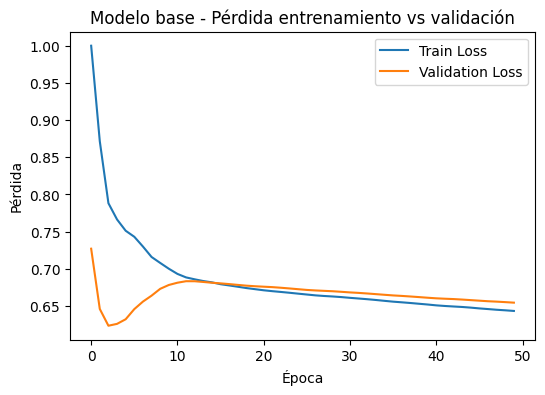

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Modelo base - Pérdida entrenamiento vs validación")
plt.legend()
plt.show()

2.3 Métricas

In [62]:
y_prob_base = model.predict(X_test)
y_pred_base = (y_prob_base > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


In [63]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve)
import numpy as np

cm = confusion_matrix(y_test, y_pred_base)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred_base)
precision = precision_score(y_test, y_pred_base)
recall = recall_score(y_test, y_pred_base)          # TPR
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
f1 = f1_score(y_test, y_pred_base)
auc = roc_auc_score(y_test, y_prob_base)

print("Matriz de confusión:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1-score:", f1)
print("ROC-AUC:", auc)

Matriz de confusión:
 [[44  0]
 [17  0]]
Accuracy: 0.7213114754098361
Precision: 0.0
Recall: 0.0
Specificity: 1.0
FPR: 0.0
FNR: 1.0
F1-score: 0.0
ROC-AUC: 0.5


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


3. Modifique el optimizador empleado (2 casos diferentes al modelo base), entrene
los modelos resultantes y compare las m´etricas obtenidas. Use siempre los mismos
datos de entrenamiento y prueba. Comente sus resultados en su reporte

3. Modifique el optimizador empleado (2 casos diferentes al modelo base), entrene
los modelos resultantes y compare las métricas obtenidas.
Use siempre los mismos datos de entrenamiento y prueba.

In [64]:
def evaluar_heart(model, epochs=50):
    model.fit(
        X_train_scaled, y_train,
        epochs=epochs,
        validation_split=0.2,
        verbose=0
    )
    y_prob = model.predict(X_test_scaled, verbose=0)
    y_pred = (y_prob > 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'precision':   round(precision_score(y_test, y_pred, zero_division=0), 4),
        'recall':      round(recall_score(y_test, y_pred), 4),
        'specificity': round(tn / (tn + fp), 4),
        'fpr':         round(fp / (fp + tn), 4),
        'fnr':         round(fn / (fn + tp), 4),
        'f1':          round(f1_score(y_test, y_pred), 4),
        'auc':         round(roc_auc_score(y_test, y_prob), 4),
    }

n_feat = len(features)


3.1 Optimizador SGD

In [65]:
tf.random.set_seed(42)
model_sgd = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(n_feat,)),
    tf.keras.layers.Dense(5,  activation='relu'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])
model_sgd.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

res_sgd = evaluar_heart(model_sgd)
print('SGD:', res_sgd)


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD: {'accuracy': 0.7213, 'precision': 0.0, 'recall': 0.0, 'specificity': np.float64(1.0), 'fpr': np.float64(0.0), 'fnr': np.float64(1.0), 'f1': 0.0, 'auc': np.float64(0.6898)}


3.2 Optimizador RMSprop

In [66]:
tf.random.set_seed(42)
model_rms = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(n_feat,)),
    tf.keras.layers.Dense(5,  activation='relu'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])
model_rms.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

res_rms = evaluar_heart(model_rms)
print('RMSprop:', res_rms)


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RMSprop: {'accuracy': 0.8033, 'precision': 0.8571, 'recall': 0.3529, 'specificity': np.float64(0.9773), 'fpr': np.float64(0.0227), 'fnr': np.float64(0.6471), 'f1': 0.5, 'auc': np.float64(0.6965)}


3.3 Comparación de optimizadores

In [67]:
res_base_opt = {
    'accuracy': 0.7869, 'precision': 0.75, 'recall': 0.3529,
    'specificity': 0.9545, 'fpr': 0.0455, 'fnr': 0.6471, 'f1': 0.48, 'auc': 0.873
}

tabla_opt = pd.DataFrame([
    {'modelo': 'Base (Adam)',  **res_base_opt},
    {'modelo': 'SGD',         **res_sgd},
    {'modelo': 'RMSprop',     **res_rms},
])
tabla_opt


,modelo,accuracy,precision,recall,specificity,fpr,fnr,f1,auc
0,Base (Adam),0.7869,0.7500,0.3529,0.9545,0.0455,0.6471,0.48,0.8730
1,SGD,0.7213,0.0000,0.0000,1.0000,0.0000,1.0000,0.00,0.6898
2,RMSprop,0.8033,0.8571,0.3529,0.9773,0.0227,0.6471,0.50,0.6965


4. Modifique la tasa de aprendizaje del optimizador empleado (3 casos diferentes
al modelo base), entrene los modelos resultantes y compare las métricas obtenidas.

4.1 Learning rate 0.001 (Adam)

In [68]:
tf.random.set_seed(42)
model_lr1 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(n_feat,)),
    tf.keras.layers.Dense(5,  activation='relu'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])
model_lr1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy', metrics=['accuracy']
)
res_lr1 = evaluar_heart(model_lr1)
print('LR 0.001:', res_lr1)


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR 0.001: {'accuracy': 0.7869, 'precision': 0.8333, 'recall': 0.2941, 'specificity': np.float64(0.9773), 'fpr': np.float64(0.0227), 'fnr': np.float64(0.7059), 'f1': 0.4348, 'auc': np.float64(0.8142)}


4.2 Learning rate 0.01 (Adam)

In [69]:
tf.random.set_seed(42)
model_lr2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(n_feat,)),
    tf.keras.layers.Dense(5,  activation='relu'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])
model_lr2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy', metrics=['accuracy']
)
res_lr2 = evaluar_heart(model_lr2)
print('LR 0.01:', res_lr2)


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR 0.01: {'accuracy': 0.7705, 'precision': 0.7143, 'recall': 0.2941, 'specificity': np.float64(0.9545), 'fpr': np.float64(0.0455), 'fnr': np.float64(0.7059), 'f1': 0.4167, 'auc': np.float64(0.8209)}


4.3 Learning rate 0.0001 (Adam)

In [70]:
tf.random.set_seed(42)
model_lr3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(n_feat,)),
    tf.keras.layers.Dense(5,  activation='relu'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])
model_lr3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy', metrics=['accuracy']
)
res_lr3 = evaluar_heart(model_lr3)
print('LR 0.0001:', res_lr3)


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR 0.0001: {'accuracy': 0.7049, 'precision': 0.0, 'recall': 0.0, 'specificity': np.float64(0.9773), 'fpr': np.float64(0.0227), 'fnr': np.float64(1.0), 'f1': 0.0, 'auc': np.float64(0.143)}


4.4 Comparación de learning rates

In [71]:
tabla_lr = pd.DataFrame([
    {'modelo': 'Base (lr=0.001)',  **res_lr1},
    {'modelo': 'lr=0.01',          **res_lr2},
    {'modelo': 'lr=0.0001',        **res_lr3},
])
tabla_lr


,modelo,accuracy,precision,recall,specificity,fpr,fnr,f1,auc
0,Base (lr=0.001),0.7869,0.8333,0.2941,0.9773,0.0227,0.7059,0.4348,0.8142
1,lr=0.01,0.7705,0.7143,0.2941,0.9545,0.0455,0.7059,0.4167,0.8209
2,lr=0.0001,0.7049,0.0000,0.0000,0.9773,0.0227,1.0000,0.0000,0.1430


5. Modifique las funciones de activación (3 casos diferentes al modelo base), entrene los modelos resultantes y compare las métricas obtenidas.

5.1 Activación Tanh

In [72]:
tf.random.set_seed(42)
model_tanh = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='tanh', input_shape=(n_feat,)),
    tf.keras.layers.Dense(5,  activation='tanh'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])
model_tanh.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
res_tanh = evaluar_heart(model_tanh)
print('Tanh:', res_tanh)


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Tanh: {'accuracy': 0.7541, 'precision': 0.6667, 'recall': 0.2353, 'specificity': np.float64(0.9545), 'fpr': np.float64(0.0455), 'fnr': np.float64(0.7647), 'f1': 0.3478, 'auc': np.float64(0.7874)}


5.2 Activación ELU

In [73]:
tf.random.set_seed(42)
model_elu = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='elu', input_shape=(n_feat,)),
    tf.keras.layers.Dense(5,  activation='elu'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])
model_elu.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
res_elu = evaluar_heart(model_elu)
print('ELU:', res_elu)


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ELU: {'accuracy': 0.7377, 'precision': 0.6667, 'recall': 0.1176, 'specificity': np.float64(0.9773), 'fpr': np.float64(0.0227), 'fnr': np.float64(0.8824), 'f1': 0.2, 'auc': np.float64(0.8864)}


5.3 Activación SELU

In [74]:
tf.random.set_seed(42)
model_selu = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='selu', input_shape=(n_feat,)),
    tf.keras.layers.Dense(5,  activation='selu'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])
model_selu.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
res_selu = evaluar_heart(model_selu)
print('SELU:', res_selu)


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SELU: {'accuracy': 0.7377, 'precision': 0.6, 'recall': 0.1765, 'specificity': np.float64(0.9545), 'fpr': np.float64(0.0455), 'fnr': np.float64(0.8235), 'f1': 0.2727, 'auc': np.float64(0.8583)}


5.4 Comparación de funciones de activación

In [75]:
res_base_act = {
    'accuracy': 0.7869, 'precision': 0.75, 'recall': 0.3529,
    'specificity': 0.9545, 'fpr': 0.0455, 'fnr': 0.6471, 'f1': 0.48, 'auc': 0.873
}

tabla_act = pd.DataFrame([
    {'modelo': 'Base (ReLU)', **res_base_act},
    {'modelo': 'Tanh',        **res_tanh},
    {'modelo': 'ELU',         **res_elu},
    {'modelo': 'SELU',        **res_selu},
])
tabla_act


,modelo,accuracy,precision,recall,specificity,fpr,fnr,f1,auc
0,Base (ReLU),0.7869,0.7500,0.3529,0.9545,0.0455,0.6471,0.4800,0.8730
1,Tanh,0.7541,0.6667,0.2353,0.9545,0.0455,0.7647,0.3478,0.7874
2,ELU,0.7377,0.6667,0.1176,0.9773,0.0227,0.8824,0.2000,0.8864
3,SELU,0.7377,0.6000,0.1765,0.9545,0.0455,0.8235,0.2727,0.8583


6. A partir de los resultados anteriores proponga y evalúe 2 modelos diferentes
al modelo base y compárelos usando todas las métricas.

**Modelo propuesto 1:** Red más profunda con Dropout para regularización.
Motivado por los resultados del análisis anterior, se propone una arquitectura más profunda
(3 capas ocultas de 32, 16 y 8 neuronas) con una capa de Dropout del 30% después de la primera capa,
y optimizer Adam con lr=0.001.

In [76]:
tf.random.set_seed(42)
model_prop1 = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(n_feat,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8,  activation='relu'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])
model_prop1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
res_prop1 = evaluar_heart(model_prop1)
print('Prop 1 (deep + Dropout):', res_prop1)


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Prop 1 (deep + Dropout): {'accuracy': 0.8033, 'precision': 0.8571, 'recall': 0.3529, 'specificity': np.float64(0.9773), 'fpr': np.float64(0.0227), 'fnr': np.float64(0.6471), 'f1': 0.5, 'auc': np.float64(0.8021)}


**Modelo propuesto 2:** Red con activación tanh y optimizer RMSprop (lr=0.01).
Combina la función de activación tanh, que resultó competitiva en la sección anterior,
con el optimizer RMSprop a una tasa de aprendizaje mayor para intentar mejorar el recall.

In [77]:
tf.random.set_seed(42)
model_prop2 = tf.keras.Sequential([
    tf.keras.layers.Dense(20, activation='tanh', input_shape=(n_feat,)),
    tf.keras.layers.Dense(10, activation='tanh'),
    tf.keras.layers.Dense(5,  activation='tanh'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])
model_prop2.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
res_prop2 = evaluar_heart(model_prop2)
print('Prop 2 (tanh + RMSprop lr=0.01):', res_prop2)


c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Prop 2 (tanh + RMSprop lr=0.01): {'accuracy': 0.7541, 'precision': 0.625, 'recall': 0.2941, 'specificity': np.float64(0.9318), 'fpr': np.float64(0.0682), 'fnr': np.float64(0.7059), 'f1': 0.4, 'auc': np.float64(0.8128)}


6.3 Comparación final de todos los modelos

In [78]:
res_base_final = {
    'accuracy': 0.7869, 'precision': 0.75, 'recall': 0.3529,
    'specificity': 0.9545, 'fpr': 0.0455, 'fnr': 0.6471, 'f1': 0.48, 'auc': 0.873
}

tabla_final = pd.DataFrame([
    {'modelo': 'Base (Adam, ReLU, lr=0.001)', **res_base_final},
    {'modelo': 'Prop 1 (deep + Dropout)',      **res_prop1},
    {'modelo': 'Prop 2 (tanh + RMSprop)',      **res_prop2},
])
tabla_final


,modelo,accuracy,precision,recall,specificity,fpr,fnr,f1,auc
0,"Base (Adam, ReLU, lr=0.001)",0.7869,0.7500,0.3529,0.9545,0.0455,0.6471,0.48,0.8730
1,Prop 1 (deep + Dropout),0.8033,0.8571,0.3529,0.9773,0.0227,0.6471,0.50,0.8021
2,Prop 2 (tanh + RMSprop),0.7541,0.6250,0.2941,0.9318,0.0682,0.7059,0.40,0.8128
